# Langchain Introduction

In [2]:
import langchain
langchain.__version__

'1.4.0'

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


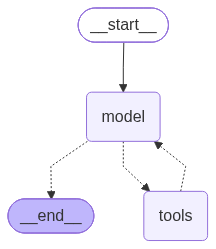

In [10]:
from langchain.agents import create_agent

def get_weather(city:str) -> str:
    """Get weather for a city"""
    return f"The weather in the {city} is sunny"

agent = create_agent(
    model = "google_genai:gemini-flash-lite-latest",
    tools=[get_weather],
    system_prompt="You are a helpful AI assitant.",
    # verbose=True
)

agent

In [12]:
response=agent.invoke({"messages":[{"role":"user", "content":"What is the weather in New york?"}]})

In [14]:
response["messages"][-1]

AIMessage(content=[{'type': 'text', 'text': 'The weather in New York is currently sunny.', 'extras': {'signature': 'El4KXAERTTIPGe+mhbl75EIyWZ4w41C09tNW6+Z7MrNRQaWMcyEXwRIxrvFVBvFqLQPq8ehwLmbPHvcHJicmse0b8fjAdAzkLVBtfLytc8BtpNo8lq9dqsUAVgHzGV82'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0762c-e35e-7282-9280-776947dcae02-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 97, 'output_tokens': 9, 'total_tokens': 106, 'input_token_details': {'cache_read': 0}})

# Different ways to integrate models

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [7]:
from langchain.chat_models import init_chat_model

model = init_chat_model(model="google_genai:gemini-flash-lite-latest")
model

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini Flash-Lite Latest', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-lite-latest', client=<google.genai.client.Client object at 0x000002662C13DE80>, default_metadata=(), model_kwargs={})

In [8]:
response  = model.invoke("hello")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [9]:
response.text

'Hello! How can I help you today?'

## other ways

from langchain_groq import ChatGroq
model = ChatGroq(model="X")

from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="X")

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-flash-lite-latest")
response = model.invoke("hello")
response.text

'Hello! How can I help you today?'

# Streaming and Batching

Streaming = showing the output while model is generating
Batch = multiple parallel requests

In [9]:
for chunk in model.stream("Write me a 200 word essay on AGI"):
    print(chunk.text, end="|", flush=True)

Artificial General| Intelligence (AGI) represents the hypothetical milestone where a machine successfully mimics human cognitive| flexibility, reasoning, and learning capabilities across any intellectual domain. Unlike narrow AI—which excels at specific tasks like chess or speech| recognition—AGI possesses the autonomy to comprehend, adapt, and apply knowledge in novel, unforeseen environments just as a human would|.

The pursuit of AGI is the holy grail of modern computer science, fueled by exponential leaps in neural network architectures, massive computational| power, and endless data streams. Proponents envision a utopian future where AGI eradicates disease, solves climate change, and autom|ates mundane labor, ushering in a post-scarcity society. By leveraging machine intelligence that vastly outpaces biological| limits, humanity could unlock scientific breakthroughs at an unprecedented velocity.

However, AGI also introduces unprecedented existential risks. Critics| and safety res

In [10]:
responses = model.batch([
    "Why do parrots fly?", 
    "Why dont penguins fly?"
])

for response in responses:
    print(response)

content=[{'type': 'text', 'text': "Like almost all birds, parrots fly primarily as a means of **survival, movement, and interacting with their environment**. \n\nHere are the main reasons why parrots fly:\n\n### 1. Finding Food and Water\nIn the wild, parrots are foragers. They fly long distances every day to find fruit, seeds, nuts, blossoms, and nectar. Being able to fly allows them to cover large territories and find seasonal food sources that are spread out.\n\n### 2. Escaping Predators\nParrots are prey animals for larger birds of prey (like hawks and eagles), snakes, and tree-climbing mammals. Flight is their primary defense mechanism, allowing them to escape danger quickly by taking to the air or darting into thick jungle canopy.\n\n### 3. Roosting and Safety at Night\nParrots are diurnal (active during the day). As evening approaches, they use flight to travel back to safe communal roosting sites, usually high up in tall trees where they are safer from ground predators while th

# Tools

In [10]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather of any city"""
    return f"It's sunny in {city}"

model_with_tool = model.bind_tools([get_weather])

In [14]:
response = model_with_tool.invoke("Whats weather in new york")
for tool_call in response.tool_calls:
    print(tool_call)

{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'call_85840', 'type': 'tool_call'}


### Tool Execution loops

In [15]:
# step 1
messages = [{"role":"user", "content":"Whats the weather in boston?"}]
ai_msg = model_with_tool.invoke(messages)
messages.append(ai_msg)

# step 2 
for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# step 3
final_response = model_with_tool.invoke(messages)
print(final_response.text)


The weather in Boston is sunny.


In [16]:
messages

[{'role': 'user', 'content': 'Whats the weather in boston?'},
 AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Boston"}'}, '__gemini_function_call_thought_signatures__': {'call_93882': 'El4KXAERTTIPnwHZkyMbzgDKlaB76Mwrx+VnYpdZzO4xFYW7dz2Q+Ofp7bDxDlnK5st8lMjXfpE4OrSjvBeU1sK71R7EO0fqmMUoy+xwDxCWgGmg/ClIAHTET4yzTxOi'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a07d01-8e7b-77c0-80c1-ab303ba8f60b-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Boston'}, 'id': 'call_93882', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 16, 'total_tokens': 65, 'input_token_details': {'cache_read': 0}}),
 ToolMessage(content="It's sunny in Boston", name='get_weather', tool_call_id='call_93882')]

# Messages
Messages are the fundamental unit of context in langchain. They represent input and output of models

they contain: 
1. role - identifies the message type
2. content - actual content of the message
3. metadata - response info, msg id, token usage

In [ ]:
# text prompt - string
model.invoke("What is AI?")

### message prompts - list of msg objects

Message types: 
- System message
- Human message
- AI message
- Tool message

In [17]:
from langchain.messages import SystemMessage, HumanMessage, AIMessage
messages = [
    SystemMessage("You are poetry expert"),
    HumanMessage('Write a poem about cats')
]

response = model.invoke(messages)
response.text

'They tread like ghosts across the floor,\nA silent step, a velvet paw,\nThen melt into the shadows deep,\nWhile all the waking world is sleep.\n\nWith eyes like jade and amber coins,\nAnd liquid grace within their loins,\nThey watch us from their throne of heights,\nLords of the lazy, sunlit lights.\n\nA purr begins—a hidden engine,\nA soothing hum, a warm redemption.\nThey deign to brush against a knee,\nThen stretch, and wander off, care-free.\n\nUntamed, though curled upon a rug,\nThey wear the mask of idle thug,\nYet hold the ancient, mystic grace\nOf gods who lost their rightful place.'

# Structured outputs

to get outputs in specific formats and schemas

## Pydantic

In [12]:
# pydantic

from pydantic import BaseModel, Field

class Movie(BaseModel):
    title:str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director:str = Field(description="Director name")
    rating: float = Field(description="Movie rating out of 10")


In [20]:
model_with_structured_output = model.with_structured_output(Movie)
model_with_structured_output

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini Flash-Lite Latest', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), model='gemini-flash-lite-latest', client=<google.genai.client.Client object at 0x0000028185171590>, default_metadata=(), model_kwargs={}), kwargs={'response_mime_type': 'application/json', 'response_json_schema': {'properti

In [21]:
model_with_structured_output.invoke("Give me details of movie inception")

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

### Nested Structure

In [22]:
class Actor(BaseModel):
    name:str
    age:int

class Movie_details(BaseModel):
    title:str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director:str = Field(description="Director name")
    rating: float | None = Field(description="Movie rating out of 10")
    actors: list[Actor]

In [24]:
model_with_structured_output = model.with_structured_output(Movie_details)
response = model_with_structured_output.invoke("Give me details of movie inception")
response

Movie_details(title='Inception', year=2010, director='Christopher Nolan', rating=8.8, actors=[Actor(name='Leonardo DiCaprio', age=49), Actor(name='Joseph Gordon-Levitt', age=43), Actor(name='Elliot Page', age=37)])

## TypedDict

In [13]:
from typing_extensions import TypedDict, Annotated

class MovieDict(TypedDict):
    """A movie with details"""
    title: Annotated[str, ..., "The title of the movie"]
    year: Annotated[str, ..., "The release year of the movie"]
    director: Annotated[str, ..., "The director of the movie"]
    rating: Annotated[str, ..., "The rating of the movie out of 10"]

model_with_typeddict = model.with_structured_output(MovieDict)
response = model_with_typeddict.invoke("Provide details about movie avengers")
response

{'title': 'The Avengers',
 'year': '2012',
 'director': 'Joss Whedon',
 'rating': '8.0'}

In [14]:
class Actor(TypedDict):
    name:str
    age:int

class Movie_details(TypedDict):
    title:str = Field(description="The title of the movie")
    year: int = Field(description="The year the movie was released")
    director:str = Field(description="Director name")
    rating: float | None = Field(description="Movie rating out of 10")
    actors: list[Actor]


model_with_typeddict = model.with_structured_output(Movie_details)
response = model_with_typeddict.invoke("Provide details about movie avengers")
response

{'title': 'The Avengers',
 'year': 2012,
 'director': 'Joss Whedon',
 'rating': 8.0,
 'actors': [{'name': 'Robert Downey Jr.', 'age': 47},
  {'name': 'Chris Evans', 'age': 31},
  {'name': 'Scarlett Johansson', 'age': 27},
  {'name': 'Mark Ruffalo', 'age': 44}]}

In [15]:
model.profile

{'name': 'Gemini Flash-Lite Latest',
 'release_date': '2026-07-21',
 'last_updated': '2026-07-21',
 'open_weights': False,
 'max_input_tokens': 1048576,
 'max_output_tokens': 65536,
 'text_inputs': True,
 'image_inputs': True,
 'audio_inputs': True,
 'pdf_inputs': True,
 'video_inputs': True,
 'text_outputs': True,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True,
 'structured_output': True,
 'attachment': True,
 'temperature': True,
 'image_url_inputs': True,
 'image_tool_message': True,
 'tool_choice': True}

In [17]:
from pydantic import BaseModel, Field

from langchain.agents import create_agent

class ContactInfo(BaseModel):
    name: str = Field(description="name of the person")
    email: str = Field(description="the email of the person")
    phone: str = Field(description = "The phone number of the person")


agent = create_agent(model = "google_genai:gemini-flash-lite-latest", response_format=ContactInfo)
result = agent.invoke({
    'messages':{"role":"user", "content":"Extract content info from john doe, 32, 30130-34332, john@gmail.com"}
})


print(result["structured_response"])


name='john doe' email='john@gmail.com' phone='30130-34332'


## Dataclass

In [18]:
from dataclasses import dataclass
from langchain.agents import create_agent

@dataclass
class ContactInfo(BaseModel):
    name: str
    email: str
    phone: str


agent = create_agent(model = "google_genai:gemini-flash-lite-latest", response_format=ContactInfo)
result = agent.invoke({
    'messages':{"role":"user", "content":"Extract content info from john doe, 32, 30130-34332, john@gmail.com"}
})


print(result["structured_response"])

name='john doe' email='john@gmail.com' phone='30130-34332'


# Middlewares

Middlewares allows us to tightly control what happens inside the agent. Middlewares are useful for various tasks such as logging, analytics, summarization, debugging, tool selection, output formatting, rate limits etc

a few common middlewares in langchain are: 
1. summarization
2. human in the loop
3. model call limit
4. tool call limit
5. PII detection

In [21]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [35]:
# summarization

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage, HumanMessage

agent = create_agent(
    model="google_genai:gemini-flash-lite-latest",
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model="google_genai:gemini-flash-lite-latest",
            trigger=("messages", 10),
            keep = ("messages", 4)
        )
    ]
)

In [36]:
config = {"configurable" : {"thread_id":"test-1"}}

In [41]:
questions = [
    "What is 2+2?",
    "What is 4+2?",
    "What is 3+23?",
    "What is Helium?",
    "What is 2+2?",
    "What is 4+2?",
    "What is 3+23?",
    "What is Helium?",
]

In [42]:
for q in questions: 
    response = agent.invoke({"messages":[HumanMessage(content=q)]}, config)
    print(f"{response}")
    print(f"response len: {len(response['messages'])}")



{'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='cd89c8fe-414d-4a93-8efa-5b1d161decba'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'signature': 'El4KXAERTTIPt7aEJ5OQ+p1U49kvxNTbmrR6+V0yQ299pZuce+57xzOrXbJlbyF5gmDvs4pBPTDkza/Q3Z6jPpW9VGxTTl+owWfhFKgxZ34CkFI8QHnvB+ENrerr5ciX'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a08106-b1ef-7fb2-955b-657804f9cab5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 7, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='What is 4+2?', additional_kwargs={}, response_metadata={}, id='01447f89-4ae5-42a1-ba2d-ceaa409121e2'), AIMessage(content=[{'type': 'text', 'text': '4 + 2 = 6', 'extras': {'signature': 'El4KXAERTTIPgkzzhIkh7C6KmEW/HlDzO/OmYASj2uS6CW+BvdlItdVA86b50LorVf

In [ ]:
# Summarization based on tokens

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage


@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model="google_genai:gemini-flash-lite-latest",
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model="google_genai:gemini-flash-lite-latest",
            trigger=("tokens", 550),
            keep = ("tokens", 200)
        )
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

In [46]:
def token_counter(messages):
    total_chars = sum(len(m.content) for m in messages)
    return total_chars // 4

In [47]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = token_counter(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    # print(f"{(response['messages'])}")

Paris: ~256 tokens, 3 messages
London: ~262 tokens, 5 messages
Tokyo: ~253 tokens, 5 messages
New York: ~254 tokens, 5 messages
Dubai: ~271 tokens, 5 messages
Singapore: ~250 tokens, 5 messages


In [48]:
# summarization based on fractions

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage


@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model="google_genai:gemini-flash-lite-latest",
    checkpointer = InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model="google_genai:gemini-flash-lite-latest",
            trigger=("fraction", 0.005), # 0.5% = ~640 tokens
            keep = ("fraction", 0.002) # 0.2% = ~256 tokens
        )
    ]
)

config = {"configurable": {"thread_id": "test-1"}}

In [49]:
for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = token_counter(response["messages"])
    fraction = tokens / 128000  
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~4 tokens (0.0031%), 2 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='75084dd8-f301-4230-bdf2-a559bd82df76'), AIMessage(content=[{'type': 'text', 'text': 'Paris has an overwhelming number of hotels, so the best place to stay really depends on your **budget**, **travel style**, and **what you want to see**. \n\nHere is a guide to the best areas to stay in Paris, followed by a curated list of top hotel recommendations across different budgets.\n\n---\n\n### 1. Where to Stay: Choosing a Neighborhood (Arrondissement)\n\n*   **1st Arrondissement (Louvre / Châtelet):** Best for first-timers who want to be right in the center, walking distance to the Louvre and the Seine.\n*   **3rd & 4th Arrondissements (Le Marais):** Trendy, historic, full of boutiques, great cafes, and nightlife. Very walkable and charming.\n*   **5th & 6th Arrondissements (Latin Quarter / Saint-Germain-des-Prés):** Classic Parisian charm, literary history, cafes (like 

## Human in the loop middleware

pauses the agent for human intervention. very important for high stakes tasks such as stock market agents, payment, sending emails, database writes etc. 

In [ ]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [55]:
agent = create_agent(
    model="google_genai:gemini-flash-lite-latest",
    checkpointer = InMemorySaver(),
    tools=[send_email_tool, read_email_tool],
    middleware = [
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve", "edit", "reject"]
                },
                "read_email_tool":False
            }
        )
    ]
)

In [56]:
config = {"configurable": {"thread_id": "test-approve"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [57]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='0b1a3881-1318-485d-9822-9c01ae8676f8'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'send_email_tool', 'arguments': '{"subject": "Hello", "body": "How are you?", "recipient": "john@test.com"}'}, '__gemini_function_call_thought_signatures__': {'call_217423': 'El4KXAERTTIPZGXYsb6gzcH5hCjNnlr5I7GTBnDmZkar6N9aPvARHRIudtwp4sQfCqzbvc2krO0yWMp/cBgGw4bY0YaMdDcx399DLL827wfyAgifF8BvVC4JE3Xz7p1H'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a08222-bc1b-7da3-9419-18f8e2fc7f85-0', tool_calls=[{'name': 'send_email_tool', 'args': {'subject': 'Hello', 'body': 'How are you?', 'recipient': 'john@test.com'}, 'id': 'call_217423', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, 'ou

In [58]:
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! needs approval...")
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result {result["messages"][-1].content}")

Paused! needs approval...
Result [{'type': 'text', 'text': 'The email has been successfully sent to john@test.com with the subject "Hello".', 'extras': {'signature': 'El4KXAERTTIP7gVyukXWB7s3Yc2TAa6005dRrLD78PzefTtsY1fO2LWlo0WMVlxyBoHJjdI5wSwrCxLJMsK8yXnsHSQ4DBi+84m0Ynx4B/VAvk0faMKFJu0zXTaESMJH'}}]


In [60]:
config = {"configurable": {"thread_id": "test-reject"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [61]:
# reject

from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! needs approval...")
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )

    print(f"Result {result["messages"][-1].content}")

Paused! needs approval...
Result [{'type': 'text', 'text': 'The email sending action was cancelled because the request was rejected. Let me know if you need help with anything else!', 'extras': {'signature': 'El4KXAERTTIPtMj5X+gC6hW2oi/IQdQ+sZruwIpvxAVzeTQJ2GyOrkbgB5FVAaK3m94qyh2mNuuUUSpstKV/GWQKAHUUjtO2zZwde45YAzgWryhSWfohck4xQ5FS6w8E'}}]


In [ ]:
config = {"configurable": {"thread_id": "test-reject"}}

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [ ]:
if "__interrupt__" in result:
    print("Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"Result: {result['messages'][-1].content}")